<a href="https://colab.research.google.com/github/arshadraza1205/Data-analysis/blob/main/Website_Traffic_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np

# Load the traffic dataset
df = pd.read_csv('traffic.csv')

# Convert date column
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Quick inspection of columns and missing values
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (226278, 9)

Missing Values:
 event         0
date          0
country      11
city         11
artist       37
album         5
track         5
isrc       7121
linkid        0
dtype: int64

First 5 rows:


,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [6]:
# 1. Total events and breakdown
total_events = len(df)
event_counts = df['event'].value_counts()

# 2. Geography breakdown
top_countries = df['country'].value_counts().head(5)
top_cities = df['city'].value_counts().head(5)

# 3. Content engagement (Top tracks/content)
top_tracks = df['track'].value_counts().head(5)

print(f"Total Logged Interactions: {total_events:,}")
print("\nInteraction Types (Pageviews vs Clicks):\n", event_counts)
print("\nTop 5 Visitor Countries:\n", top_countries)
print("\nTop 5 Consumed Tracks/Pages:\n", top_tracks)

Total Logged Interactions: 226,278

Interaction Types (Pageviews vs Clicks):
 event
pageview    142015
click        55732
preview      28531
Name: count, dtype: int64

Top 5 Visitor Countries:
 country
Saudi Arabia     47334
India            42992
United States    32558
France           15661
Iraq              8260
Name: count, dtype: int64

Top 5 Consumed Tracks/Pages:
 track
Jalebi Baby                             40841
Beautiful                               10658
Beautiful Day                            9751
ily (i love you baby) (feat. Emilee)     7533
So Pretty                                5664
Name: count, dtype: int64


/tmp/ipykernel_502/2234325733.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_countries.values, y=top_10_countries.index, palette='crest')


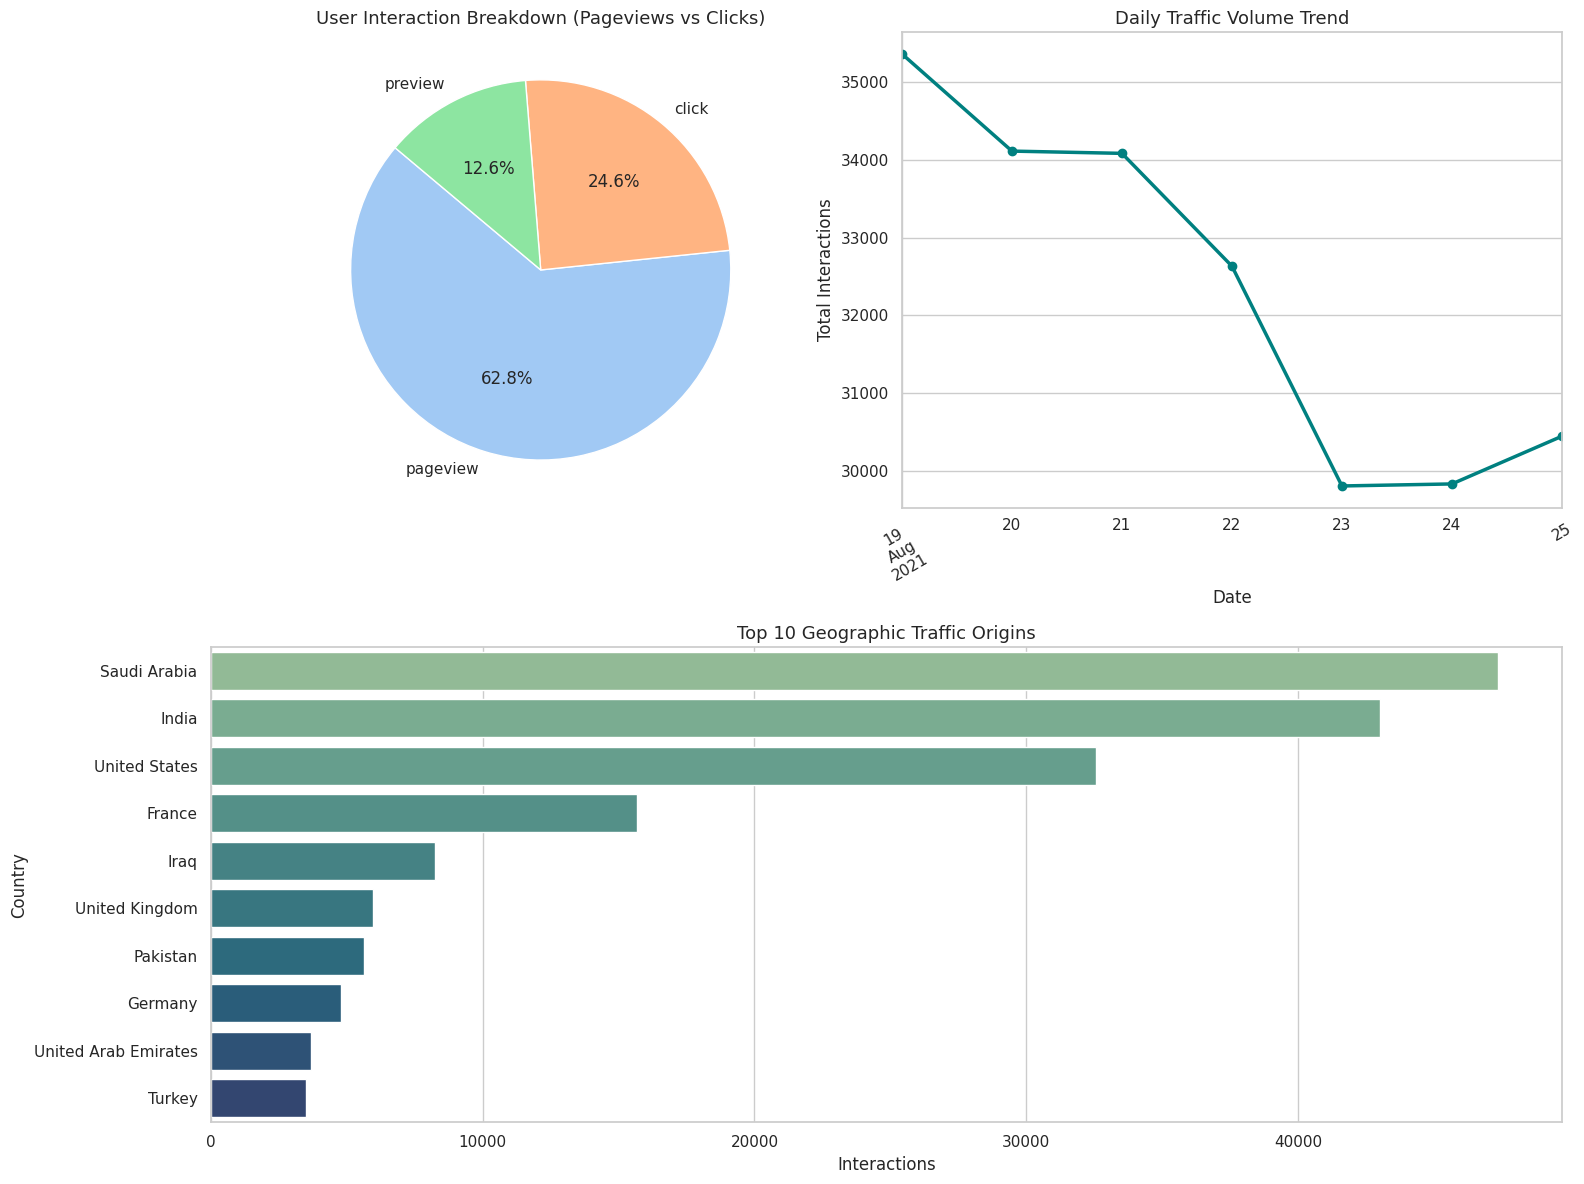

Combined dashboard saved as task3_combined_dashboard.png


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.figure(figsize=(16, 12))

# 1. Event Type Distribution (Pageview vs Click)
plt.subplot(2, 2, 1)
palette = sns.color_palette('pastel')
plt.pie(event_counts, labels=event_counts.index, autopct='%1.1f%%', startangle=140, colors=palette)
plt.title('User Interaction Breakdown (Pageviews vs Clicks)', fontsize=13)

# 2. Daily Traffic Trend
plt.subplot(2, 2, 2)
daily_traffic = df.groupby('date').size()
daily_traffic.plot(kind='line', marker='o', color='teal', linewidth=2.5)
plt.title('Daily Traffic Volume Trend', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Total Interactions')
plt.xticks(rotation=30)

# 3. Top 10 Countries by Visitor Share
plt.subplot(2, 1, 2)
top_10_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_10_countries.values, y=top_10_countries.index, palette='crest')
plt.title('Top 10 Geographic Traffic Origins', fontsize=13)
plt.xlabel('Interactions')
plt.ylabel('Country')

plt.tight_layout()
plt.savefig('task3_combined_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print("Combined dashboard saved as task3_combined_dashboard.png")